In [33]:
import sys
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

In [34]:
from pyspark.sql import functions as F

transactions = spark.read.parquet("../data/curated/transactions")
customers = spark.read.parquet("../data/curated/df_customers_demo")
consumer_details = spark.read.parquet("../data/curated/consumer_user_details")

print("transactions")
transactions.printSchema()

print("customers")
customers.printSchema()

print("consumer_details")
consumer_details.printSchema()


transactions.show(5, truncate=False)
customers.show(5, truncate=False)
consumer_details.show(5, truncate=False)

transactions
root
 |-- user_id: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)

customers
root
 |-- consumer_id: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)

consumer_details
root
 |-- user_id: long (nullable = true)
 |-- consumer_id: long (nullable = true)

+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|11138  |63290521567 |41.239626303220014|09f6132a-a6a8-47a2-a03e-383ddbf5feaa|2022-08-25    |
|22285  

In [35]:
from pyspark.sql import functions as F

# matching user_id types
transactions_clean = transactions.withColumn(
    "user_id",
    F.col("user_id").cast("long")
)

consumer_map = (
    consumer_details
    .select("user_id", "consumer_id")
    .dropDuplicates(["user_id"])
)

# attaching consumer_id to every transaction
tx_consumer = (
    transactions_clean
    .join(
        consumer_map,
        on="user_id",
        how="left"
    )
)

tx_consumer.printSchema()
tx_consumer.show(5, truncate=False)

# checking for unmatched
tx_consumer.select(
    F.count("*").alias("transactions"),
    F.sum(F.col("consumer_id").isNull().cast("int")).alias("unmatched")
).show()

root
 |-- user_id: long (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- consumer_id: long (nullable = true)

+-------+------------+------------------+------------------------------------+--------------+-----------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|consumer_id|
+-------+------------+------------------+------------------------------------+--------------+-----------+
|11138  |63290521567 |41.239626303220014|09f6132a-a6a8-47a2-a03e-383ddbf5feaa|2022-08-25    |401483     |
|22285  |63465140133 |8.815286645396842 |f4fc1a3b-a5b1-4d75-b459-cf9bc12e1347|2022-08-25    |416278     |
|11139  |21359184622 |66.46301590693417 |b1a52524-b6e6-42a5-9726-687033350acc|2022-08-25    |505718     |
|22285  |75034515922 |19.654995598411727|ba240514-5dea-4059-ac35-5917d4853188|2022-08-25    |416278     |
|1

In [36]:
# consumer demographic mapping
consumer_demo = (
    customers
    .select(
        "consumer_id",
        "state",
        "postcode",
        "gender"
    )
    .dropDuplicates(["consumer_id"])
)

(
    customers
    .groupBy("consumer_id")
    .agg(
        F.countDistinct("postcode").alias("n_postcodes"),
        F.countDistinct("gender").alias("n_genders"),
        F.countDistinct("state").alias("n_states")
    )
    .orderBy(F.desc("n_postcodes"))
    .show(20)
)

+-----------+-----------+---------+--------+
|consumer_id|n_postcodes|n_genders|n_states|
+-----------+-----------+---------+--------+
|     511685|          1|        1|       1|
|     845767|          1|        1|       1|
|     640907|          1|        1|       1|
|     254118|          1|        1|       1|
|    1028770|          1|        1|       1|
|     238454|          1|        1|       1|
|    1010604|          1|        1|       1|
|     511108|          1|        1|       1|
|    1125864|          1|        1|       1|
|     760024|          1|        1|       1|
|    1241834|          1|        1|       1|
|     822059|          1|        1|       1|
|    1424601|          1|        1|       1|
|     136621|          1|        1|       1|
|      94534|          1|        1|       1|
|     225441|          1|        1|       1|
|     131147|          1|        1|       1|
|     858467|          1|        1|       1|
|     307578|          1|        1|       1|
|    13009

In [37]:
# determining type
consumer_demo = (
    customers
    .select(
        "consumer_id",
        "state",
        "postcode",
        "gender"
    )
    .dropDuplicates(["consumer_id"])
)

In [38]:
# consumer feature table (tags)
consumer_features = (
    tx_consumer
    .groupBy("consumer_id")
    .agg(
        F.sum("dollar_value").alias("total_spend"),
        F.count("*").alias("transaction_count"),
        F.avg("dollar_value").alias("avg_transaction"),
        F.expr("percentile_approx(dollar_value, 0.5)")
            .alias("median_transaction"),
        F.max("dollar_value").alias("max_transaction"),
        F.countDistinct("merchant_abn").alias("unique_merchants"),
        F.min("order_datetime").alias("first_purchase"),
        F.max("order_datetime").alias("last_purchase")
    )
    .withColumn(
        "active_days",
        F.datediff("last_purchase", "first_purchase") + 1
    )
)

consumer_features.show(10, truncate=False)

+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+
|consumer_id|total_spend       |transaction_count|avg_transaction   |median_transaction|max_transaction   |unique_merchants|first_purchase|last_purchase|active_days|
+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+
|30         |113480.34027334329|601              |188.81920178592893|63.6689358590169  |8226.239031619009 |366             |2021-03-03    |2022-10-24   |601        |
|257        |93617.13292229742 |598              |156.5503895021696 |62.28629071956282 |3282.1552597705427|362             |2021-03-02    |2022-10-26   |604        |
|799        |102388.20505898299|587              |174.42624371206642|68.02294454272288 |5019.942466886326 |363             |2021-02-28    |2022-10-25   |605        |
|946

e.g. consumer 226 was a very frequent BNPL user, making 599 purchases worth roughly $86,000 across 20 months, and purchased from 339 different merchants.

In [39]:
# adding demographics
consumer_features = (
    consumer_features
    .join(
        consumer_demo,
        on="consumer_id",
        how="left"
    )
)

In [40]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ranking consumers by transaction frequency
frequency_window = Window.orderBy(
    F.desc("transaction_count"),
    F.desc("total_spend")
)

consumer_features = (
    consumer_features
    .withColumn(
        "frequency_rank",
        F.dense_rank().over(frequency_window)
    )
)

In [41]:
# checking the tables
consumer_features \
    .orderBy("frequency_rank") \
    .show(20, truncate=False)

26/10/04 21:09:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 2

+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+-----+--------+-----------+--------------+
|consumer_id|total_spend       |transaction_count|avg_transaction   |median_transaction|max_transaction   |unique_merchants|first_purchase|last_purchase|active_days|state|postcode|gender     |frequency_rank|
+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+-----+--------+-----------+--------------+
|467988     |132520.9319430767 |620              |213.74343861786562|64.1158184566759  |28535.333088208343|363             |2021-03-01    |2022-10-26   |605        |QLD  |4560    |Female     |1             |
|1393512    |125178.15800983479|620              |201.90025485457224|58.96039864872814 |19835.843542471302|356             |2021-03-01    |2022-10-26   |605        |NSW

26/10/04 21:09:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [42]:
# loading merchants
merchants = spark.read.parquet("../data/curated/df_merchants")

merchants.printSchema()
merchants.show(10, truncate=False)

root
 |-- merchant_abn: long (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)

+------------+-----------------------------+--------------------------------------------------------------------+----------------------------------------+------------+---------+-------------------+------------------+--------------+------------------+-----------------------+
|merchant_abn|merchant_name                |tags                                                                |category                                |revenue_band|take_rate|category_group     |total_revenue     |n_transactions|avg

In [43]:
# quintiles to rank merchants by consumer behaviour (20% divisions)
quintile_window = Window.orderBy(F.desc("transaction_count"))

consumer_features = (
    consumer_features
    .withColumn(
        "frequency_quintile",
        F.ntile(5).over(quintile_window)
    )
)

In [44]:
# consumer frequency table
consumer_features = (
    consumer_features
    .withColumn(
        "frequency_segment",
        F.when(F.col("frequency_quintile") == 1, "Very High Frequency")
         .when(F.col("frequency_quintile") == 2, "High Frequency")
         .when(F.col("frequency_quintile") == 3, "Moderate Frequency")
         .when(F.col("frequency_quintile") == 4, "Low Frequency")
         .otherwise("Very Low Frequency")
    )
)

consumer_features.show(20, truncate=False)

26/10/04 21:09:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:09:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 2

+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+-----+--------+-----------+--------------+------------------+-------------------+
|consumer_id|total_spend       |transaction_count|avg_transaction   |median_transaction|max_transaction   |unique_merchants|first_purchase|last_purchase|active_days|state|postcode|gender     |frequency_rank|frequency_quintile|frequency_segment  |
+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+-----+--------+-----------+--------------+------------------+-------------------+
|467988     |132520.9319430767 |620              |213.74343861786562|64.1158184566759  |28535.333088208343|363             |2021-03-01    |2022-10-26   |605        |QLD  |4560    |Female     |1             |1                 |Very High Frequency|
|1393512    

26/10/04 21:10:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:10:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:10:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:10:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [45]:
# loading merchant data
merchants = spark.read.parquet("../data/curated/df_merchants")

tx_consumer = tx_consumer.withColumn(
    "merchant_abn",
    F.col("merchant_abn").cast("long")
)

tx_full = (
    tx_consumer
    .join(
        merchants.select(
            "merchant_abn",
            "merchant_name",
            "category",
            "revenue_band",
            "take_rate"
        ),
        on="merchant_abn",
        how="left"
    )
)

In [46]:
# calculating what consumers buy through BNPL
consumer_category = (
    tx_full
    .groupBy("consumer_id", "category")
    .agg(
        F.sum("dollar_value").alias("category_spend"),
        F.count("*").alias("category_transactions")
    )
)

In [47]:
# category diversity and preferences
from pyspark.sql.window import Window

w = Window.partitionBy("consumer_id")

consumer_category = (
    consumer_category
    .withColumn(
        "total_category_spend",
        F.sum("category_spend").over(w)
    )
    .withColumn(
        "category_share",
        F.col("category_spend") / F.col("total_category_spend")
    )
)
category_features = (
    consumer_category
    .groupBy("consumer_id")
    .agg(
        F.countDistinct("category").alias("unique_categories"),
        F.max("category_share").alias("top_category_share"),
        (
            -F.sum(
                F.when(
                    F.col("category_share") > 0,
                    F.col("category_share") * F.log(F.col("category_share"))
                ).otherwise(0)
            )
        ).alias("category_entropy")
    )
)

In [48]:
# joining it to consumer table
consumer_features = (
    consumer_features
    .join(category_features, on="consumer_id", how="left")
)

# by frequency ranking
frequency_window = Window.orderBy(
    F.desc("transaction_count")
)

consumer_features = (
    consumer_features
    .withColumn(
        "frequency_rank",
        F.dense_rank().over(frequency_window)
    )
    .withColumn(
        "frequency_quintile",
        F.ntile(5).over(frequency_window)
    )
)

In [49]:
# tags!!!!
consumer_features = (
    consumer_features
    .withColumn(
        "frequency_segment",
        F.when(F.col("frequency_quintile") == 1, "Very High Frequency")
         .when(F.col("frequency_quintile") == 2, "High Frequency")
         .when(F.col("frequency_quintile") == 3, "Moderate Frequency")
         .when(F.col("frequency_quintile") == 4, "Low Frequency")
         .otherwise("Very Low Frequency")
    )
)

consumer_features.show(20, truncate=False)

26/10/04 21:10:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:10:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:10:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:10:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:10:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:10:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 2

+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+-----+--------+-----------+--------------+------------------+-------------------+-----------------+-------------------+------------------+
|consumer_id|total_spend       |transaction_count|avg_transaction   |median_transaction|max_transaction   |unique_merchants|first_purchase|last_purchase|active_days|state|postcode|gender     |frequency_rank|frequency_quintile|frequency_segment  |unique_categories|top_category_share |category_entropy  |
+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+-----+--------+-----------+--------------+------------------+-------------------+-----------------+-------------------+------------------+
|108767     |106934.95435876213|620              |172.47573283671312|73.37115772772664 |

In [50]:
# attaching transactions back into the equation
tx_ranked = (
    tx_full
    .join(
        consumer_features.select(
            "consumer_id",
            "frequency_rank",
            "frequency_quintile",
            "frequency_segment",
            "transaction_count",
            "total_spend"
        ),
        on="consumer_id",
        how="left"
    )
)

In [51]:
# summarising merchants for analysis vs consumers
merchant_consumer_profile = (
    tx_ranked
    .groupBy(
        "merchant_abn",
        "merchant_name",
        "category"
    )
    .agg(
        F.countDistinct("consumer_id").alias("unique_consumers"),
        F.avg("transaction_count").alias("avg_customer_frequency"),
        F.avg("total_spend").alias("avg_customer_total_spend"),
        F.avg(
            F.when(F.col("frequency_quintile") == 1, 1).otherwise(0)
        ).alias("top_20pct_customer_share"),
        F.sum("dollar_value").alias("merchant_bnpl_spend"),
        F.count("*").alias("merchant_transactions")
    )
)

# checking by frequency customers
merchant_consumer_profile \
    .orderBy(F.desc("top_20pct_customer_share")) \
    .show(20, truncate=False)

26/10/04 21:11:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 2

+------------+----------------------------------+-------------------------------------------------------------+----------------+----------------------+------------------------+------------------------+-------------------+---------------------+
|merchant_abn|merchant_name                     |category                                                     |unique_consumers|avg_customer_frequency|avg_customer_total_spend|top_20pct_customer_share|merchant_bnpl_spend|merchant_transactions|
+------------+----------------------------------+-------------------------------------------------------------+----------------+----------------------+------------------------+------------------------+-------------------+---------------------+
|39150153670 |Aliquam Eu Institute              |antique shops - sales, repairs, and restoration services     |1               |601.0                 |137859.36078138507      |1.0                     |38089.93927161727  |1                    |
|99989036621 |NULL      

In [52]:
# loading external dataset
external = spark.read.parquet("../data/curated/final_external_enriched")

external.printSchema()
external.show(5, truncate=False)
print(external.columns)

root
 |-- order_datetime: date (nullable = true)
 |-- postcode: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)
 |-- Me

In [53]:
enriched = spark.read.parquet("../data/curated/final_external_enriched")

In [54]:
# finding socioeconomic tags
[c for c in enriched.columns if any(
    key in c.lower()
    for key in [
        "seifa", "irsd", "irsad", "income",
        "unemployment", "age", "rba"
    ]
)]

['Median_age_persons',
 'Median_mortgage_repay_monthly',
 'Average_num_psns_per_bedroom',
 'Average_household_size',
 'poa_irsad_score',
 'poa_irsad_decile',
 'poa_irsd_score',
 'poa_irsd_decile',
 'rba_cash_rate_pct',
 'rba_rate_change',
 'rba_rate_hike_day']

In [55]:
#  socioeconomic disadvantage tag using IRSD decile; lower IRSD decile = greater relative socioeconomic disadvantage

enriched = enriched.withColumn(
    "socioeconomic_area",
    F.when(F.col("poa_irsd_decile") <= 3, "Higher Disadvantage")
     .when(F.col("poa_irsd_decile") <= 7, "Middle")
     .otherwise("Lower Disadvantage")
)

In [56]:
# relative advantage/disadvantage tag

enriched = enriched.withColumn(
    "advantage_area",
    F.when(F.col("poa_irsad_decile") <= 3, "Lower Advantage")
     .when(F.col("poa_irsad_decile") <= 7, "Middle")
     .otherwise("Higher Advantage")
)

In [57]:
# age tag using terciles (no cutoff)

age_low, age_high = enriched.approxQuantile(
    "Median_age_persons",
    [0.33, 0.67],
    0.01
)

enriched = enriched.withColumn(
    "age_area_tag",
    F.when(
        F.col("Median_age_persons") <= age_low,
        "Younger Area"
    )
    .when(
        F.col("Median_age_persons") <= age_high,
        "Middle-age Area"
    )
    .otherwise("Older Area")
)

In [58]:
# mortgage tag (useful for RBA rate analysis later)

mortgage_low, mortgage_high = enriched.approxQuantile(
    "Median_mortgage_repay_monthly",
    [0.33, 0.67],
    0.01
)

enriched = enriched.withColumn(
    "mortgage_cost_tag",
    F.when(
        F.col("Median_mortgage_repay_monthly") <= mortgage_low,
        "Lower Mortgage Cost Area"
    )
    .when(
        F.col("Median_mortgage_repay_monthly") <= mortgage_high,
        "Middle Mortgage Cost Area"
    )
    .otherwise("Higher Mortgage Cost Area")
)

In [59]:
# results of tagging
enriched.select(
    "consumer_id",
    "postcode",
    "poa_irsd_decile",
    "poa_irsad_decile",
    "Median_age_persons",
    "Median_mortgage_repay_monthly",
    "socioeconomic_area",
    "advantage_area",
    "age_area_tag",
    "mortgage_cost_tag"
).show(20, truncate=False)

+-----------+--------+---------------+----------------+------------------+-----------------------------+-------------------+----------------+---------------+-------------------------+
|consumer_id|postcode|poa_irsd_decile|poa_irsad_decile|Median_age_persons|Median_mortgage_repay_monthly|socioeconomic_area |advantage_area  |age_area_tag   |mortgage_cost_tag        |
+-----------+--------+---------------+----------------+------------------+-----------------------------+-------------------+----------------+---------------+-------------------------+
|179208     |2782    |8.0            |8.0             |50.00000033778364 |2079.999978121255            |Lower Disadvantage |Higher Advantage|Older Area     |Higher Mortgage Cost Area|
|845250     |2070    |10.0           |10.0            |40.99999996929092 |3595.6619925469913           |Lower Disadvantage |Higher Advantage|Middle-age Area|Higher Mortgage Cost Area|
|845250     |2070    |10.0           |10.0            |40.99999996929092 |3595.6

In [60]:
# too much repetition with this in terms of consumers so reducing it down as one demographic tag per consumer
consumer_socio = (
    enriched
    .select(
        "consumer_id",
        "postcode",
        "poa_irsd_decile",
        "poa_irsad_decile",
        "Median_age_persons",
        "Median_mortgage_repay_monthly",
        "socioeconomic_area",
        "advantage_area",
        "age_area_tag",
        "mortgage_cost_tag"
    )
    .dropDuplicates(["consumer_id"])
)

In [61]:
# attacking onto consumer frequency table
consumer_features = (
    consumer_features
    .join(
        consumer_socio,
        on="consumer_id",
        how="left"
    )
)
consumer_features.show(20, truncate=False)

26/10/04 21:11:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 2

+-----------+------------------+-----------------+------------------+------------------+------------------+----------------+--------------+-------------+-----------+-----+--------+-----------+--------------+------------------+-------------------+-----------------+-------------------+------------------+--------+---------------+----------------+------------------+-----------------------------+-------------------+----------------+---------------+-------------------------+
|consumer_id|total_spend       |transaction_count|avg_transaction   |median_transaction|max_transaction   |unique_merchants|first_purchase|last_purchase|active_days|state|postcode|gender     |frequency_rank|frequency_quintile|frequency_segment  |unique_categories|top_category_share |category_entropy  |postcode|poa_irsd_decile|poa_irsad_decile|Median_age_persons|Median_mortgage_repay_monthly|socioeconomic_area |advantage_area  |age_area_tag   |mortgage_cost_tag        |
+-----------+------------------+-----------------+--

In [62]:
from collections import Counter

print("repeated columns:", [c for c, n in Counter(consumer_features.columns).items() if n > 1])

seen, new_names, keep = set(), [], []
for c in consumer_features.columns:
    if c in seen:
        new_names.append(c + "__dup")
    else:
        seen.add(c); new_names.append(c); keep.append(c)

cf_out = consumer_features.toDF(*new_names).select(*keep)
print(len(cf_out.columns), "repeated columns:", cf_out.columns)

cf_out.write.mode("overwrite").parquet("../data/curated/consumer_features")
print("rows saved:", spark.read.parquet("../data/curated/consumer_features").count())

repeated columns: ['postcode']
27 repeated columns: ['consumer_id', 'total_spend', 'transaction_count', 'avg_transaction', 'median_transaction', 'max_transaction', 'unique_merchants', 'first_purchase', 'last_purchase', 'active_days', 'state', 'postcode', 'gender', 'frequency_rank', 'frequency_quintile', 'frequency_segment', 'unique_categories', 'top_category_share', 'category_entropy', 'poa_irsd_decile', 'poa_irsad_decile', 'Median_age_persons', 'Median_mortgage_repay_monthly', 'socioeconomic_area', 'advantage_area', 'age_area_tag', 'mortgage_cost_tag']


26/10/04 21:11:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 21:11:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/04 2

rows saved: 24081


remember this is the postcode caveat only!!!! not the consumer themsleves so it is the area they live in, not necessarily their actual socioeconomic status e.g. consumer 187772 made 620 BNPL transactions during the observed period, spent about $103.8k in total, had an average transaction of $167.49, a typical transaction of about $65, and purchased from 372 different merchants.

avergae is $167 and median is $65 which means there is significant overdispersion (right-skew)

whereas consumer 1393512 has the same frequency of 620 BNPL transactions, but has a higher total spend of $125.2k in total, avergae transaction of #20190, typical transaction of $59, and purchased from 356 different merchants.

the table gives a look into how consumers interact with different merchants and how; e.g. high-frequency + high-spend, high-frequency + moderate-spend, high-frequency + very diversified merchants, high-frequency + occasional huge-ticket purchases

this was because frequency still remains the same for many consumers but behavioural differences can be seen in how they spend money through BNPL

In [63]:
# consumer x month dataset for interest rate analysis
from pyspark.sql import functions as F

consumer_month = (
    enriched
    .withColumn(
        "month",
        F.date_trunc("month", "order_datetime")
    )
    .groupBy("consumer_id", "month")
    .agg(
        F.sum("dollar_value").alias("monthly_spend"),
        F.count("*").alias("monthly_transactions"),
        F.avg("dollar_value").alias("avg_transaction"),
        F.countDistinct("merchant_abn").alias("unique_merchants"),
        F.countDistinct("category").alias("unique_categories")
    )
)

consumer_month.show(20, truncate=False)

+-----------+-------------------+------------------+--------------------+------------------+----------------+-----------------+
|consumer_id|month              |monthly_spend     |monthly_transactions|avg_transaction   |unique_merchants|unique_categories|
+-----------+-------------------+------------------+--------------------+------------------+----------------+-----------------+
|528961     |2021-11-01 00:00:00|7585.052406911844 |31                  |244.67910990038206|29              |15               |
|409073     |2022-02-01 00:00:00|4918.239230020209 |14                  |351.30280214430064|14              |8                |
|656355     |2021-04-01 00:00:00|12505.814751772254|35                  |357.3089929077787 |31              |12               |
|1396       |2021-12-01 00:00:00|4868.157805143921 |41                  |118.73555622302246|39              |16               |
|1399261    |2021-10-01 00:00:00|7129.914190881838 |26                  |274.2274688800707 |26          

In [64]:
# adding RBA and aggregating it to monthly timestamps
rba_daily = (
    enriched
    .select(
        "order_datetime",
        "rba_cash_rate_pct",
        "rba_rate_change",
        "rba_rate_hike_day"
    )
    .dropDuplicates(["order_datetime"])
)
rba_monthly = (
    rba_daily
    .withColumn(
        "month",
        F.date_trunc("month", "order_datetime")
    )
    .groupBy("month")
    .agg(
        F.avg("rba_cash_rate_pct").alias("cash_rate"),
        F.sum("rba_rate_change").alias("monthly_rate_change"),
        F.max("rba_rate_hike_day").alias("rate_hike_month")
    )
    .orderBy("month")
)

rba_monthly.show(30, truncate=False)

+-------------------+-------------------+-------------------+---------------+
|month              |cash_rate          |monthly_rate_change|rate_hike_month|
+-------------------+-------------------+-------------------+---------------+
|2021-02-01 00:00:00|0.1                |0.0                |0              |
|2021-03-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-04-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-05-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-06-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-07-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-08-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-09-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-10-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-11-01 00:00:00|0.10000000000000005|0.0                |0  

In [65]:
# rebuilding consumer-month WITHOUT any RBA columns
consumer_month_base = (
    tx_full
    .withColumn(
        "month",
        F.date_trunc("month", "order_datetime")
    )
    .groupBy("consumer_id", "month")
    .agg(
        F.sum("dollar_value").alias("monthly_spend"),
        F.count("*").alias("monthly_transactions"),
        F.avg("dollar_value").alias("avg_transaction"),
        F.countDistinct("merchant_abn").alias("unique_merchants"),
        F.countDistinct("category").alias("unique_categories")
    )
)

In [66]:
# stuff is saying NULL so lets fix it
rba_monthly.orderBy("month").show(30, truncate=False)
rba_daily.agg(
    F.min("order_datetime").alias("first_date"),
    F.max("order_datetime").alias("last_date")
).show()

+-------------------+-------------------+-------------------+---------------+
|month              |cash_rate          |monthly_rate_change|rate_hike_month|
+-------------------+-------------------+-------------------+---------------+
|2021-02-01 00:00:00|0.1                |0.0                |0              |
|2021-03-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-04-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-05-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-06-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-07-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-08-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-09-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-10-01 00:00:00|0.10000000000000005|0.0                |0              |
|2021-11-01 00:00:00|0.10000000000000005|0.0                |0  

In [67]:
rba = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .parquet("../data/curated/rba_cash_rate_daily_clean.parquet")
)

rba.printSchema()
rba.show(10, truncate=False)

root
 |-- order_datetime: timestamp_ntz (nullable = true)
 |-- effective_date: timestamp_ntz (nullable = true)
 |-- cash_rate_target_pct: double (nullable = true)
 |-- rate_change: double (nullable = true)
 |-- rate_hike_day: long (nullable = true)

+-------------------+-------------------+--------------------+-----------+-------------+
|order_datetime     |effective_date     |cash_rate_target_pct|rate_change|rate_hike_day|
+-------------------+-------------------+--------------------+-----------+-------------+
|2021-02-28 00:00:00|2021-02-03 00:00:00|0.1                 |0.0        |0            |
|2021-03-01 00:00:00|2021-02-03 00:00:00|0.1                 |0.0        |0            |
|2021-03-02 00:00:00|2021-02-03 00:00:00|0.1                 |0.0        |0            |
|2021-03-03 00:00:00|2021-03-03 00:00:00|0.1                 |0.0        |0            |
|2021-03-04 00:00:00|2021-03-03 00:00:00|0.1                 |0.0        |0            |
|2021-03-05 00:00:00|2021-03-03 00:00:

In [68]:
from pyspark.sql import Row
from pyspark.sql import functions as F

rba_changes = spark.createDataFrame([
    Row(effective_date="2021-02-28", cash_rate=0.10),
    Row(effective_date="2022-05-04", cash_rate=0.35),
    Row(effective_date="2022-06-08", cash_rate=0.85),
    Row(effective_date="2022-07-06", cash_rate=1.35),
    Row(effective_date="2022-08-03", cash_rate=1.85),
    Row(effective_date="2022-09-07", cash_rate=2.35),
    Row(effective_date="2022-10-05", cash_rate=2.60)
]).withColumn(
    "effective_date",
    F.to_date("effective_date")
)

In [69]:
# creating a RBA calendar for all interest rates
calendar = (
    spark.range(1)
    .select(
        F.explode(
            F.sequence(
                F.to_date(F.lit("2021-02-28")),
                F.to_date(F.lit("2022-10-31")),
                F.expr("interval 1 day")
            )
        ).alias("date")
    )
)

In [70]:
# daily and monthly
from pyspark.sql.window import Window

rba_daily_fixed = (
    calendar
    .join(
        rba_changes,
        calendar.date >= rba_changes.effective_date,
        "left"
    )
    .withColumn(
        "rn",
        F.row_number().over(
            Window.partitionBy("date")
                  .orderBy(F.desc("effective_date"))
        )
    )
    .filter(F.col("rn") == 1)
    .select(
        "date",
        "cash_rate"
    )
)

rba_monthly_fixed = (
    rba_daily_fixed
    .withColumn(
        "month",
        F.date_trunc("month", "date")
    )
    .groupBy("month")
    .agg(
        F.avg("cash_rate").alias("cash_rate")
    )
    .orderBy("month")
)

rba_monthly_fixed.show(30, truncate=False)

+-------------------+-------------------+
|month              |cash_rate          |
+-------------------+-------------------+
|2021-02-01 00:00:00|0.1                |
|2021-03-01 00:00:00|0.10000000000000005|
|2021-04-01 00:00:00|0.10000000000000005|
|2021-05-01 00:00:00|0.10000000000000005|
|2021-06-01 00:00:00|0.10000000000000005|
|2021-07-01 00:00:00|0.10000000000000005|
|2021-08-01 00:00:00|0.10000000000000005|
|2021-09-01 00:00:00|0.10000000000000005|
|2021-10-01 00:00:00|0.10000000000000005|
|2021-11-01 00:00:00|0.10000000000000005|
|2021-12-01 00:00:00|0.10000000000000005|
|2022-01-01 00:00:00|0.10000000000000005|
|2022-02-01 00:00:00|0.10000000000000005|
|2022-03-01 00:00:00|0.10000000000000005|
|2022-04-01 00:00:00|0.10000000000000005|
|2022-05-01 00:00:00|0.32580645161290306|
|2022-06-01 00:00:00|0.7333333333333336 |
|2022-07-01 00:00:00|1.2693548387096782 |
|2022-08-01 00:00:00|1.817741935483872  |
|2022-09-01 00:00:00|2.2500000000000004 |
|2022-10-01 00:00:00|2.56774193548

In [71]:
# joining both
consumer_month = (
    consumer_month_base
    .join(
        rba_monthly_fixed,
        on="month",
        how="left"
    )
    .withColumn(
        "tightening_period",
        F.when(
            F.col("month") >= F.to_timestamp(F.lit("2022-05-01")),
            1
        ).otherwise(0)
    )
)

In [72]:
# RUN THIS AND THE ABOVE CELL AFTER DOING EVERYTHING UNDERNEATH BECAUSE THE RBA WAS MISSING AT FIRST SO I REBUILT IT
# cash rate does not overtly change so creating an overall monthly time series to get a useful summary
monthly_summary = (
    consumer_month
    .groupBy("month")
    .agg(
        F.sum("monthly_spend").alias("total_bnpl_spend"),
        F.sum("monthly_transactions").alias("total_transactions"),
        F.countDistinct("consumer_id").alias("active_consumers"),
        F.avg("cash_rate").alias("cash_rate")
    )
    .withColumn(
        "avg_transaction_check",
        F.col("total_bnpl_spend") / F.col("total_transactions")
    )
    .orderBy("month")
)

monthly_summary.show(30, truncate=False)

+-------------------+--------------------+------------------+----------------+-------------------+---------------------+
|month              |total_bnpl_spend    |total_transactions|active_consumers|cash_rate          |avg_transaction_check|
+-------------------+--------------------+------------------+----------------+-------------------+---------------------+
|2021-02-01 00:00:00|2784089.493476756   |17107             |12259           |0.10000000000000038|162.74563006235786   |
|2021-03-01 00:00:00|9.10815811790008E7  |546333            |24081           |0.10000000000001134|166.71440527846715   |
|2021-04-01 00:00:00|9.311185361582883E7 |560680            |24081           |0.10000000000001134|166.06951133592926   |
|2021-05-01 00:00:00|1.0600091336339617E8|636666            |24081           |0.10000000000001134|166.4937555380626    |
|2021-06-01 00:00:00|1.0361150741815723E8|627148            |24081           |0.10000000000001134|165.21061602390063   |
|2021-07-01 00:00:00|1.096182083

BNPL usage remained relatively resilient during the initial RBA tightening cycle. although the cash rate increased rapidly from May 2022, transaction frequency and total BNPL expenditure did not show an immediate proportional decline, and average transaction size remained broadly stable. this may not immediately prove that cash rates have no effect but could be seen towards the fact that BNPL holds resilient; if compared to other forms of purchasing, this could show a preference for BNPL over other purchasing forms (potential future analysis)

In [73]:
# pre/post comparison!!! ALSO THIS POINT ONWARDS IS DIFFERENT ANALYSIS AND DOESNT COUNT TOWARDS THE ABOVE RBA REMODELLING FOR THE 
# MONTHLY SUMMARY
monthly_analysis = (
    monthly_summary
    .filter(F.col("month") >= F.to_timestamp(F.lit("2021-03-01")))
    .withColumn(
        "spend_per_active_consumer",
        F.col("total_bnpl_spend") / F.col("active_consumers")
    )
    .withColumn(
        "transactions_per_active_consumer",
        F.col("total_transactions") / F.col("active_consumers")
    )
    .withColumn(
        "tightening_period",
        F.when(
            F.col("month") >= F.to_timestamp(F.lit("2022-05-01")),
            1
        ).otherwise(0)
    )
)

In [74]:
# pre and post RBA tightening
pre_post = (
    monthly_analysis
    .groupBy("tightening_period")
    .agg(
        F.avg("spend_per_active_consumer")
            .alias("avg_spend_per_consumer"),

        F.avg("transactions_per_active_consumer")
            .alias("avg_transactions_per_consumer"),

        F.avg("avg_transaction_check")
            .alias("avg_transaction_value"),

        F.avg("cash_rate")
            .alias("avg_cash_rate")
    )
    .orderBy("tightening_period")
)

pre_post.show(truncate=False)

+-----------------+----------------------+-----------------------------+---------------------+-------------------+
|tightening_period|avg_spend_per_consumer|avg_transactions_per_consumer|avg_transaction_value|avg_cash_rate      |
+-----------------+----------------------+-----------------------------+---------------------+-------------------+
|0                |4685.640630494182     |28.143675808432253           |166.4996513896019    |0.10000000000001137|
|1                |5379.283034649093     |32.46133189374749            |165.71915905577438   |1.4939964157705656 |
+-----------------+----------------------+-----------------------------+---------------------+-------------------+



In [75]:
# regression model time
monthly_pd = (
    monthly_analysis
    .orderBy("month")
    .toPandas()
)

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [76]:
# checking for overdispersion
count_check = (
    consumer_month
    .select("monthly_transactions")
    .agg(
        F.avg("monthly_transactions").alias("mean_count"),
        F.variance("monthly_transactions").alias("variance_count")
    )
)

count_check.show()

+-----------------+-----------------+
|       mean_count|   variance_count|
+-----------------+-----------------+
|28.74288034113619|72.20505753040045|
+-----------------+-----------------+



significant overdisperion!!!! we're doing a NB model 

In [77]:
nb_pd = (
    consumer_month
    .select(
        "consumer_id",
        "month",
        "monthly_transactions",
        "cash_rate"
    )
    .filter(F.col("month") >= F.to_timestamp(F.lit("2021-03-01")))
    .orderBy("month")
    .toPandas()
)

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [78]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

nb_pd["month"] = pd.to_datetime(nb_pd["month"])

month_map = {
    month: i
    for i, month in enumerate(sorted(nb_pd["month"].unique()))
}

nb_pd["trend"] = nb_pd["month"].map(month_map)

In [79]:
print(nb_pd.head())
print(nb_pd[["monthly_transactions", "cash_rate", "trend"]].describe())
print(nb_pd.isna().sum())

   consumer_id      month  monthly_transactions  cash_rate  trend
0        54430 2021-03-01                    28        0.1      0
1      1212819 2021-03-01                    26        0.1      0
2       395344 2021-03-01                    21        0.1      0
3      1343547 2021-03-01                    22        0.1      0
4      1356405 2021-03-01                    23        0.1      0
       monthly_transactions      cash_rate          trend
count         481620.000000  481620.000000  481620.000000
mean              29.438973       0.518199       9.500000
std                7.383160       0.774099       5.766287
min                7.000000       0.100000       0.000000
25%               24.000000       0.100000       4.750000
50%               29.000000       0.100000       9.500000
75%               34.000000       0.427688      14.250000
max               68.000000       2.567742      19.000000
consumer_id             0
month                   0
monthly_transactions    0
cash

In [80]:
# NB model!
nb_model = smf.negativebinomial(
    "monthly_transactions ~ cash_rate + trend",
    data=nb_pd
).fit()

print(nb_model.summary())

Optimization terminated successfully.
         Current function value: 3.350546
         Iterations: 14
         Function evaluations: 17
         Gradient evaluations: 17
                      NegativeBinomial Regression Results                       
Dep. Variable:     monthly_transactions   No. Observations:               481620
Model:                 NegativeBinomial   Df Residuals:                   481617
Method:                             MLE   Df Model:                            2
Date:                  Sun, 04 Oct 2026   Pseudo R-squ.:                 0.01481
Time:                          21:13:12   Log-Likelihood:            -1.6137e+06
converged:                         True   LL-Null:                   -1.6380e+06
Covariance Type:              nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2498 

In [81]:
# clustered standard errors incl
nb_model_clustered = smf.negativebinomial(
    "monthly_transactions ~ cash_rate + trend",
    data=nb_pd
).fit(
    cov_type="cluster",
    cov_kwds={"groups": nb_pd["consumer_id"]}
)

print(nb_model_clustered.summary())

Optimization terminated successfully.
         Current function value: 3.350546
         Iterations: 14
         Function evaluations: 17
         Gradient evaluations: 17
                      NegativeBinomial Regression Results                       
Dep. Variable:     monthly_transactions   No. Observations:               481620
Model:                 NegativeBinomial   Df Residuals:                   481617
Method:                             MLE   Df Model:                            2
Date:                  Sun, 04 Oct 2026   Pseudo R-squ.:                 0.01481
Time:                          21:13:15   Log-Likelihood:            -1.6137e+06
converged:                         True   LL-Null:                   -1.6380e+06
Covariance Type:                cluster   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2498 

In [82]:
# incidence rate ratios for cash rate
irr_cash_rate = np.exp(
    nb_model_clustered.params["cash_rate"]
)

print("Cash-rate IRR:", irr_cash_rate)
pct_effect = (irr_cash_rate - 1) * 100

print(
    f"Estimated percentage change in expected monthly transactions "
    f"for a 1 percentage-point increase in the cash rate: "
    f"{pct_effect:.2f}%"
)

Cash-rate IRR: 0.9974458508345212
Estimated percentage change in expected monthly transactions for a 1 percentage-point increase in the cash rate: -0.26%


In [83]:
cash_coef = nb_model_clustered.params["cash_rate"]
cash_pvalue = nb_model_clustered.pvalues["cash_rate"]

print("Cash-rate coefficient:", cash_coef)
print("Cash-rate p-value:", cash_pvalue)
print("Cash-rate IRR:", irr_cash_rate)
print("Percent effect:", pct_effect)

Cash-rate coefficient: -0.002557416569268764
Cash-rate p-value: 2.883794623049454e-07
Cash-rate IRR: 0.9974458508345212
Percent effect: -0.2554149165478803


a 1 percentage-point increase in the RBA cash rate is associated with about a 0.26% decrease in expected monthly BNPL transaction frequency among active consumers. therefore, BNPL activity continued to grow during the 2022 tightening period, reflecting a strong underlying time trend in usage. however, after controlling for this trend, the negative binomial model identifies a statistically significant but economically modest negative association between the RBA cash rate and monthly transaction frequency.

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


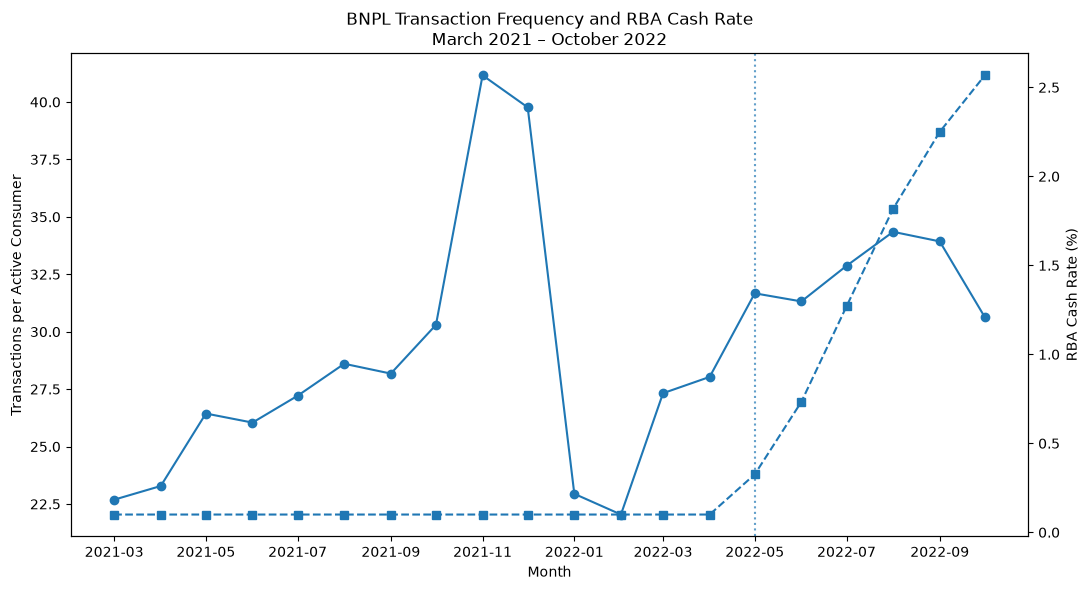

In [84]:
# line chart
import matplotlib.pyplot as plt
import pandas as pd

plot_pd = (
    monthly_analysis
    .orderBy("month")
    .select(
        "month",
        "transactions_per_active_consumer",
        "cash_rate"
    )
    .toPandas()
)

plot_pd["month"] = pd.to_datetime(plot_pd["month"])

fig, ax1 = plt.subplots(figsize=(11, 6))

# BNPL transaction frequency
ax1.plot(
    plot_pd["month"],
    plot_pd["transactions_per_active_consumer"],
    marker="o",
    label="Transactions per Active Consumer"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Transactions per Active Consumer")

# axis for RBA cash rate
ax2 = ax1.twinx()

ax2.plot(
    plot_pd["month"],
    plot_pd["cash_rate"],
    marker="s",
    linestyle="--",
    label="RBA Cash Rate"
)

ax2.set_ylabel("RBA Cash Rate (%)")

# beginning of tightening cycle
ax1.axvline(
    pd.Timestamp("2022-05-01"),
    linestyle=":",
    alpha=0.7
)

plt.title(
    "BNPL Transaction Frequency and RBA Cash Rate\n"
    "March 2021 – October 2022"
)

fig.tight_layout()
plt.show()